# WEEK 3: California Housing

| Key              | Value                                                                                                                                                                                                                                                                                                            |
|:-----------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Week01** | Resampling and Cross Validation                                                                                                                                                                                                                                                                                            |
| **Course Names** | Machine Learning and Data Science.                                                                                                                                                                                               |
| **Submission Deadline**     | October 7, 2026, 11:55 PM                                                                                                                                                                                                                                                                                          |
| **Student Name & Number**     | Edward Chisaka - 1774058                                                                                                                                                                                                                                                                                                    |
| **Contact**      | edward.chisaka@stud.hslu.ch                                                                                                                                                                                                                                                                                           |
| **Note**         | **California Housing**.<br/> _Visualize the data._.<br/> _TFit the linear regression and show the coefficients on a train set. Check assumptions of the model. Predict for the test set hypothetical rows._. <br/> GitHub citation: [BibTeX](https://github.com/CH-CHISAKA/Machine_Learning_and_Data_Science/tree/main/04-assignments/03-assignment) |

# 01: Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# 02: Load Data

In [18]:
independent_var, dependent_var = fetch_california_housing(
    return_X_y = True,
    as_frame = True
    )
# Display the independent_variable data 
display(independent_var.head())

# Display the dependent variable data
display(dependent_var.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

# 03: EDA - Exploratory Data Analysis

In [30]:
### ---- Understanding the Independent Variable data ----

# Rows, Columns
print("Independent variable shape:", independent_var.shape)

# Data types
print(f"Independent variable data types {independent_var.info()}")

# Data summary 
display("Independent variable data summary", independent_var.describe())

Independent variable shape: (20640, 8)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
Independent variable data types None


'Independent variable data summary'

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [37]:
### ---- Understanding the Dependent Variable data ----

# Rows and Columns
print("Dependent variables contains rows and columns", dependent_var.shape)

# Data types 
print("Dependent variable contains the following data types:", dependent_var.info())

# Summary of the data 
print(f"Summay of the dependent variable data: {dependent_var.describe()}")

Dependent variables contains rows and columns (20640,)
<class 'pandas.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: MedHouseVal
Non-Null Count  Dtype  
--------------  -----  
20640 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB
Dependent variable contains the following data types: None
Summay of the dependent variable data: count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


# 04: Data Visualization

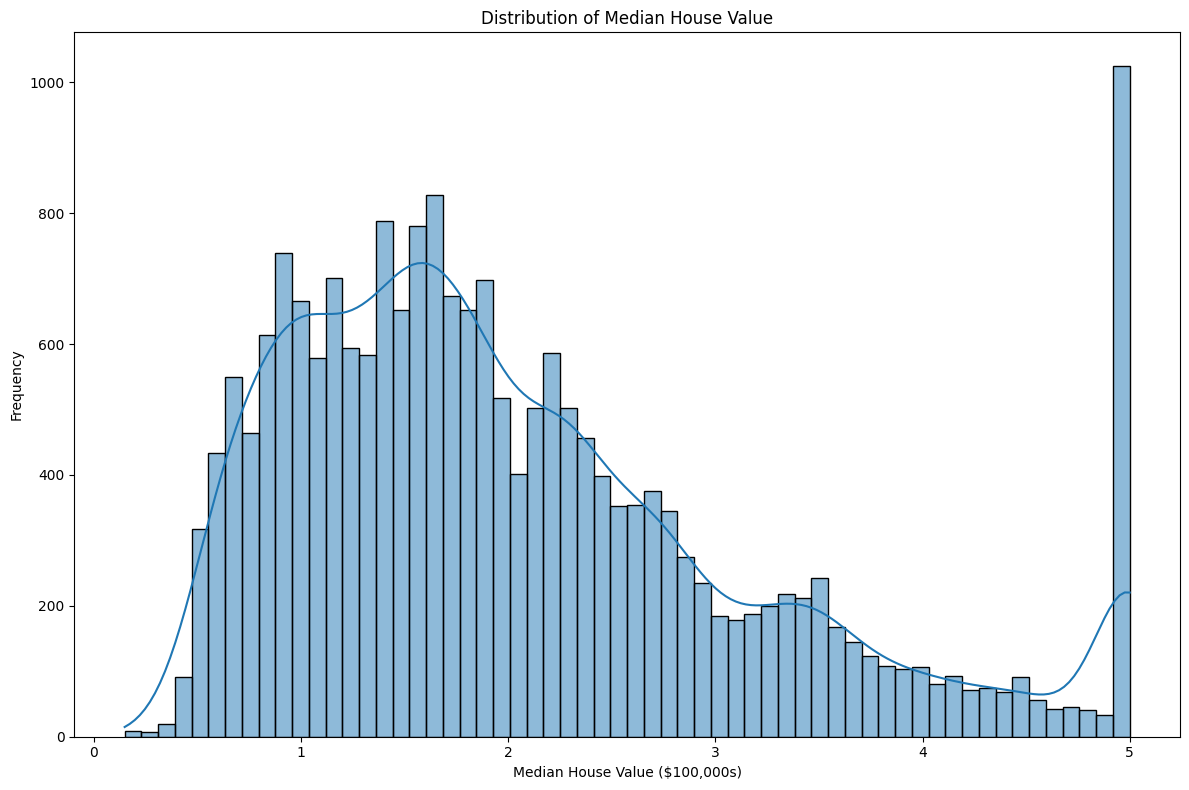

In [52]:
### --- Distribution of the target ----

plt.figure(figsize=(12,8))

sns.histplot(dependent_var, bins = 60, kde = True)

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value ($100,000s)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

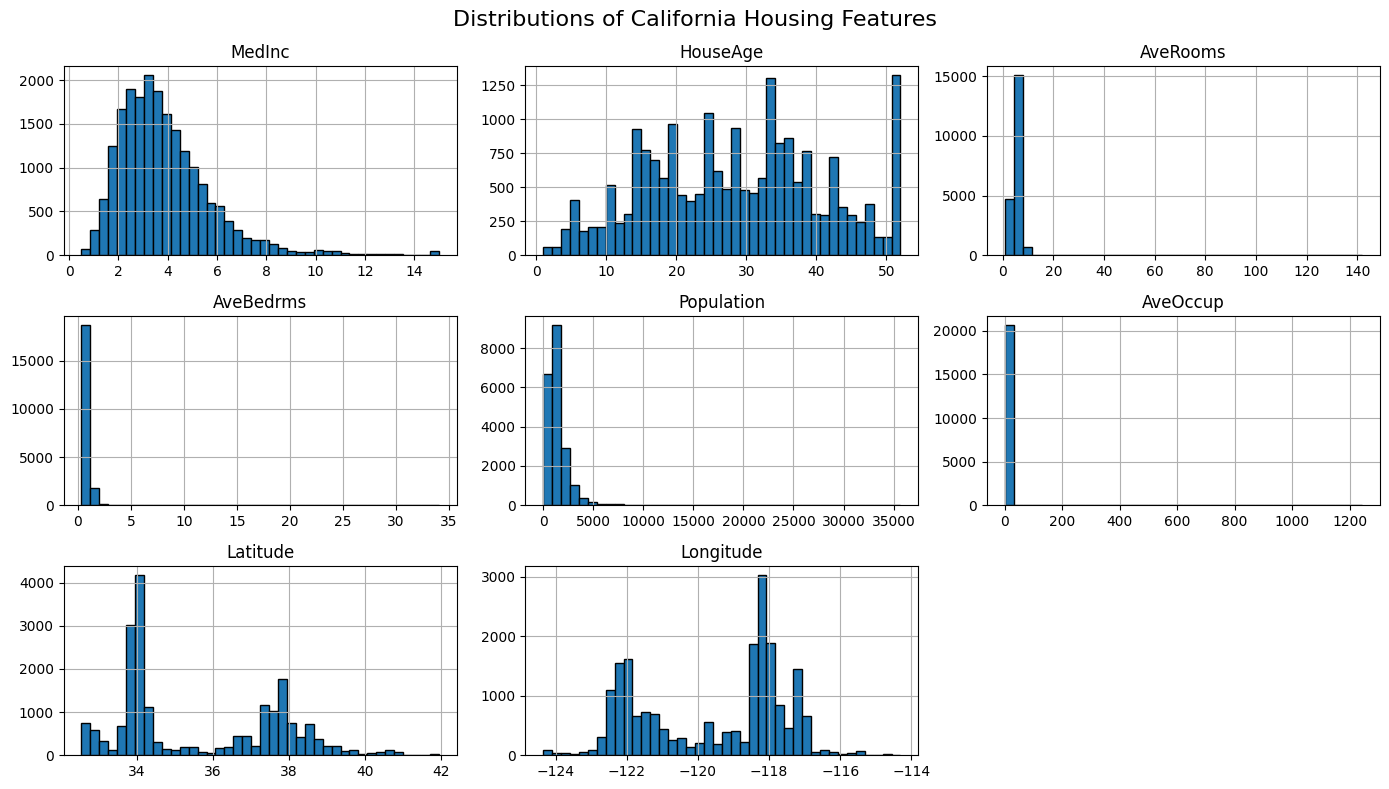

In [63]:
### --- Distribution of all Predictors ---

independent_var.hist(figsize=(14, 8), bins=40, edgecolor="black")

plt.suptitle("Distributions of California Housing Features", fontsize=16)
plt.tight_layout()
plt.show()

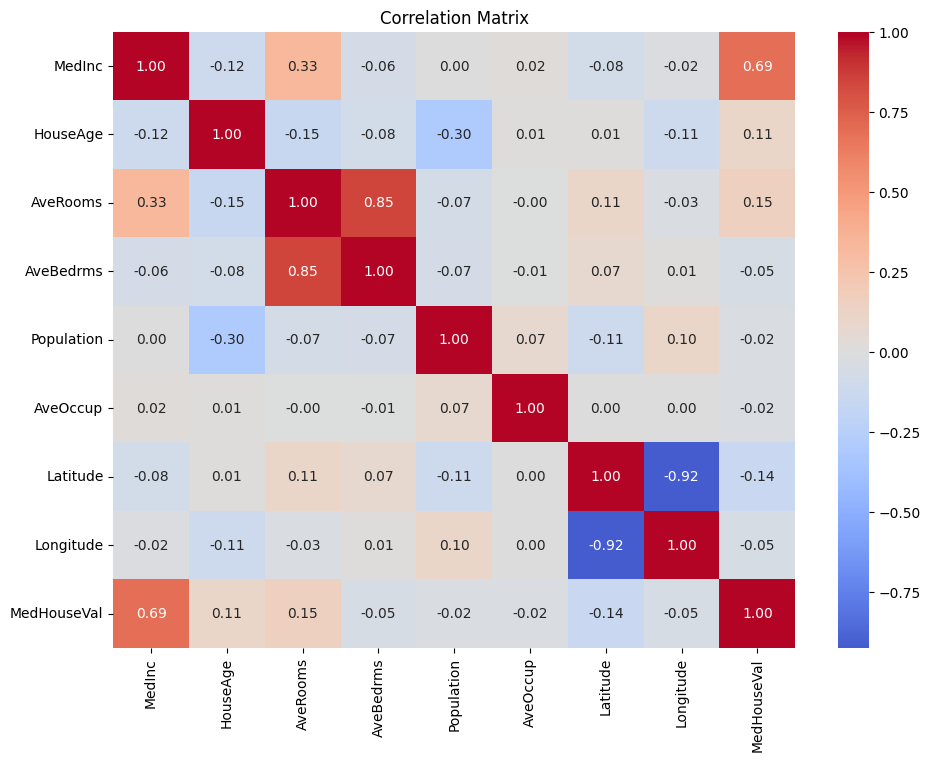

In [67]:
### --- Correlation Matrix ---

plt.figure(figsize=(11,8))

corr_matrix = pd.concat([independent_var, dependent_var.rename("MedHouseVal")], axis=1).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
# plt.tight_layout
plt.show()

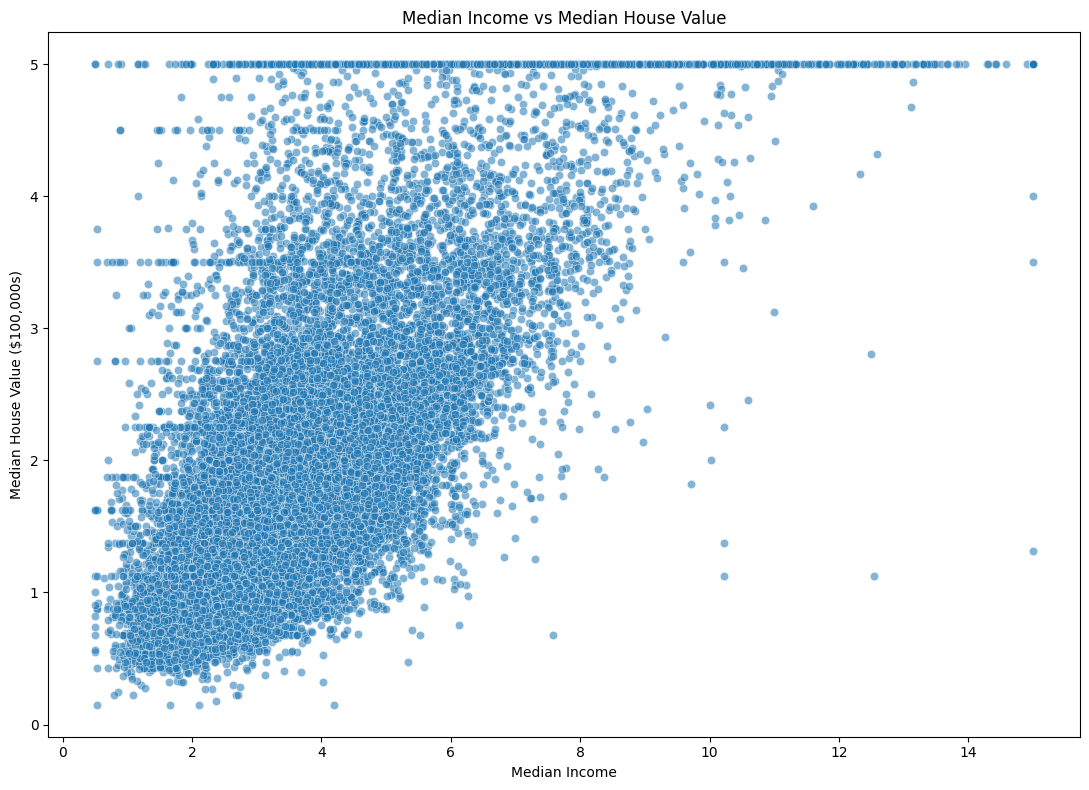

In [75]:
### --- Relationship between income and house value ---

plt.figure(figsize=(11,8))

sns.scatterplot(
    x=independent_var["MedInc"],
    y=dependent_var,
    alpha=0.55
)

plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value ($100,000s)")
plt.tight_layout()
plt.show()

# 05: Train/test split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    independent_var,
    dependent_var,
    test_size=0.20,
    random_state=42
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 16512
Testing observations: 4128


# 6: Fit the Linear Regression Model

In [79]:
model = LinearRegression()

# Fit/train the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [80]:
### --- Coefficients ---
coefficients = pd.DataFrame({
    "Feature": X_train.columns, 
    "Coefficient": model.coef_
})

display(coefficients)

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [83]:
### --- Model Intercept ---
print("Intercept:", model.intercept_)

Intercept: -37.02327770606416


# 7:  Evaluate the Model on the Test Set

In [85]:
y_pred = model.predict(X_test)

# Mean Square Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Square Error
rmse = np.sqrt(mse)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error:        {mse:.4f}")
print(f"Root Mean Squared Error:   {rmse:.4f}")
print(f"Mean Absolure Error:       {mse:.4f}")
print(f"R²:                        {r2:.4f}")

Mean Squared Error:        0.5559
Root Mean Squared Error:   0.7456
Mean Absolure Error:       0.5559
R²:                        0.5758


In [86]:
### --- Actual vs Predicted ---
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Residual": y_test.values - y_pred
})

display(results.head(10))

,Actual,Predicted,Residual
0,0.47700,0.719123,-0.242123
1,0.45800,1.764017,-1.306017
2,5.00001,2.709659,2.290351
3,2.18600,2.838926,-0.652926
4,2.78000,2.604657,0.175343
5,1.58700,2.011754,-0.424754
6,1.98200,2.645500,-0.663500
7,1.57500,2.168755,-0.593755
8,3.40000,2.740746,0.659254
9,4.46600,3.915615,0.550385


# 8: Assumptions of Linear Regression

In [90]:
### --- Calculate Residual ---

y_train_pred = model.predict(X_train)

residuals = y_train - y_train_pred

display(residual)

14196   -0.907258
8267     1.331894
17445   -0.921355
14265   -0.631895
2271    -0.648128
           ...   
11284   -0.820264
11964   -0.466888
5390     0.182201
860     -0.005751
15795    0.976268
Name: MedHouseVal, Length: 16512, dtype: float64

## 8.1: Linearity

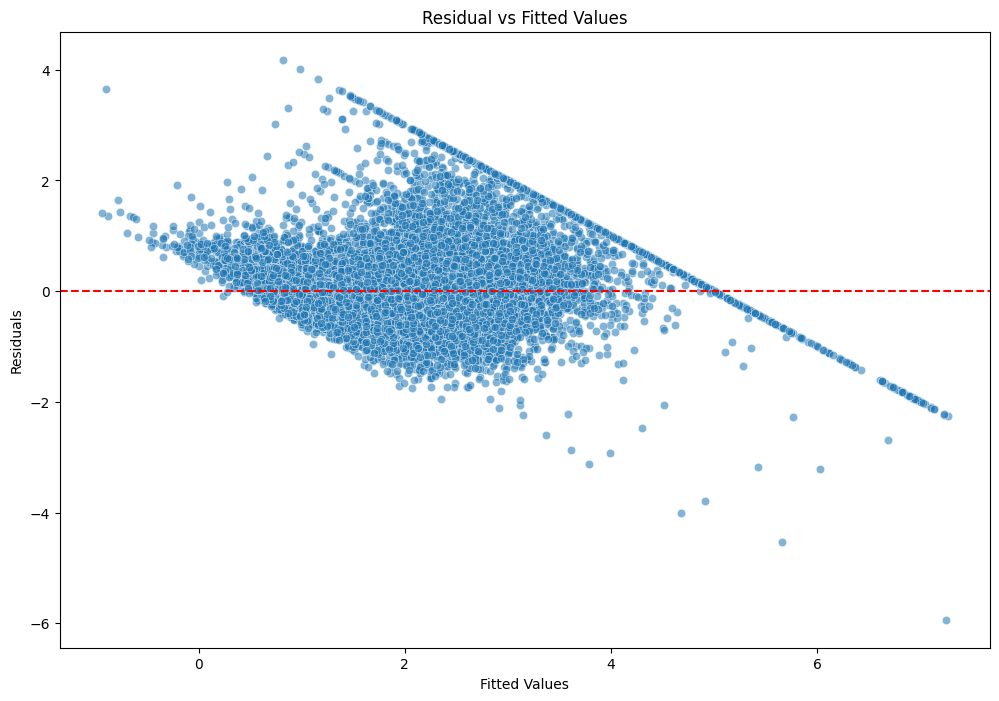

In [93]:
### --- Linearity ---
"""
A residual-vs-fitted plot is useful for detecting systematic nonlinear patterns.
"""

plt.figure(figsize=(12,8))

sns.scatterplot(
    x=y_train_pred,
    y=residuals,
    alpha=0.55
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residual vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.show()

The residuals are randomly scattered around zero.

## 8.2: Homoscedasticity

In [99]:
### --- Homoscedasticity ---
"""
The variance of the residuals should be approximately constant across fitted values.
"""

X_train_sm = sm.add_constant(X_train)

ols_model = sm.OLS(
    y_train,
    X_train_sm
).fit()

bp_test = het_breuschpagan(
    ols_model.resid,
    ols_model.model.exog
)

bp_labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

bp_results = pd.Series(
    bp_test,
    index=bp_labels
)

display(bp_results)

LM Statistic     1.170513e+03
LM p-value      2.250979e-247
F Statistic      1.573917e+02
F p-value       1.088277e-256
dtype: float64

Reject the null hypothesis of homoscedasticity, there is strong evidence of heteroscedasticity in the OLS residuals.


# 9: Normality of Residuals

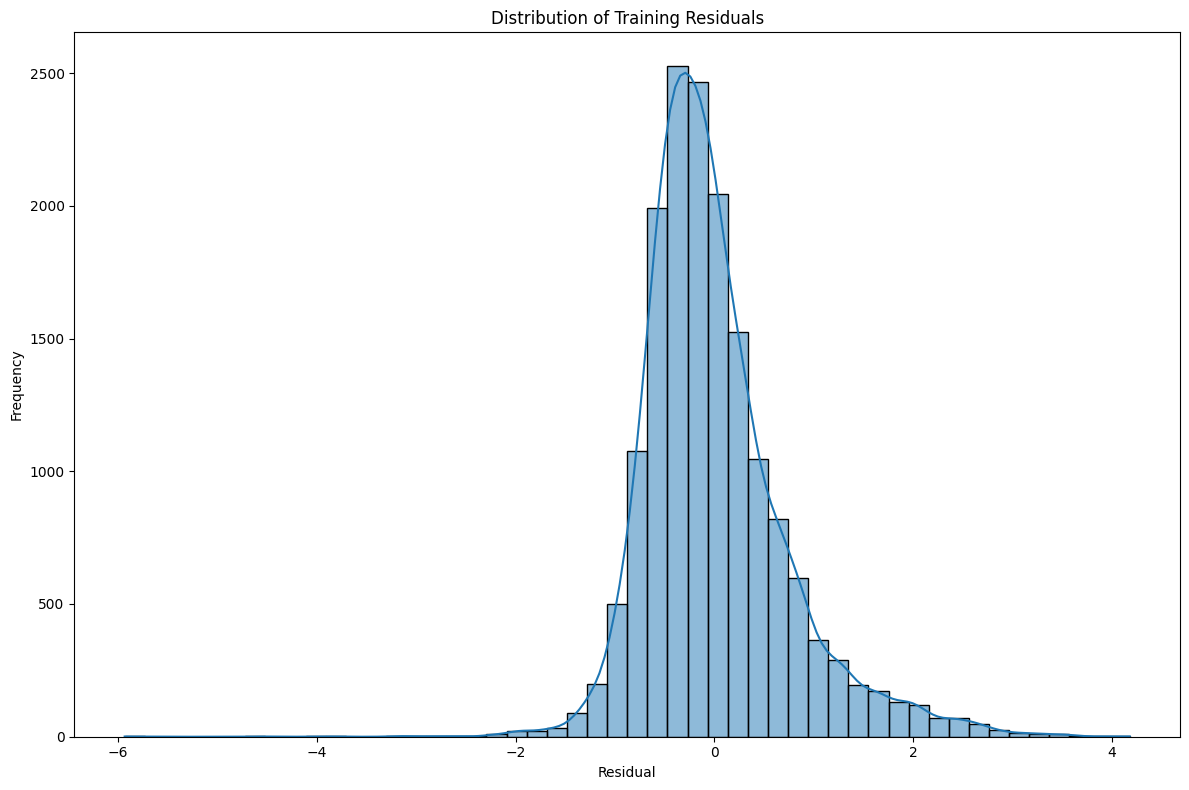

In [105]:
### --- Histogram ----

plt.figure(figsize=(12, 8))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Distribution of Training Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

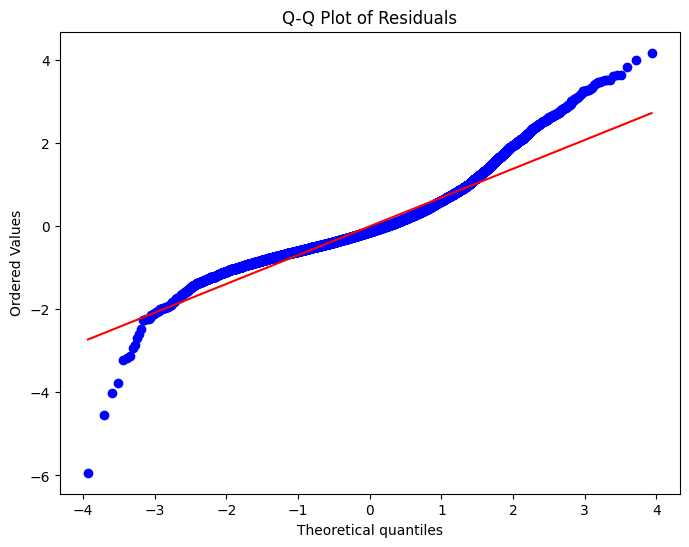

In [107]:
### --- Q-Q plot ---
plt.figure(figsize=(8, 6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals")
plt.show()

# 10. Independence

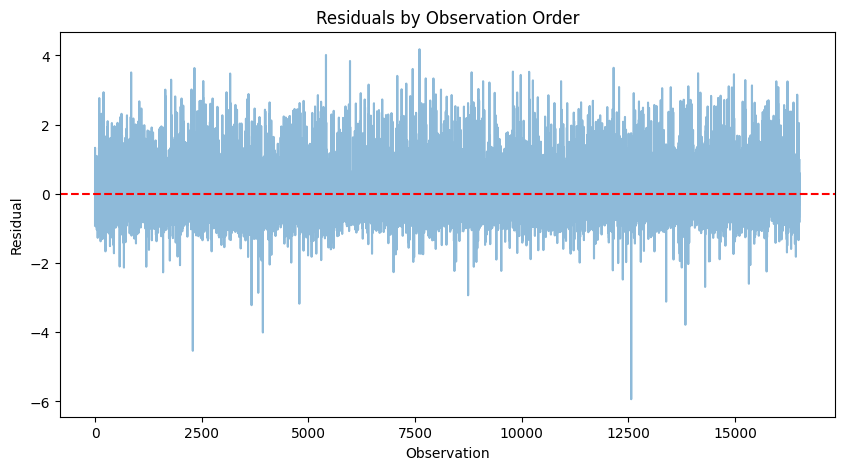

In [110]:
plt.figure(figsize=(10, 5))

plt.plot(
    residuals.values,
    alpha=0.5
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residuals by Observation Order")
plt.xlabel("Observation")
plt.ylabel("Residual")

plt.show()

# 11. Multicollinearity

In [111]:
X_vif = sm.add_constant(X_train)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

display(vif)

,Feature,VIF
0,const,16901.024982
1,MedInc,2.539815
2,HouseAge,1.237337
3,AveRooms,7.917240
4,AveBedrms,6.609200
5,Population,1.134824
6,AveOccup,1.009733
7,Latitude,9.206134
8,Longitude,8.875984


# 12. Summary diagnostic plots

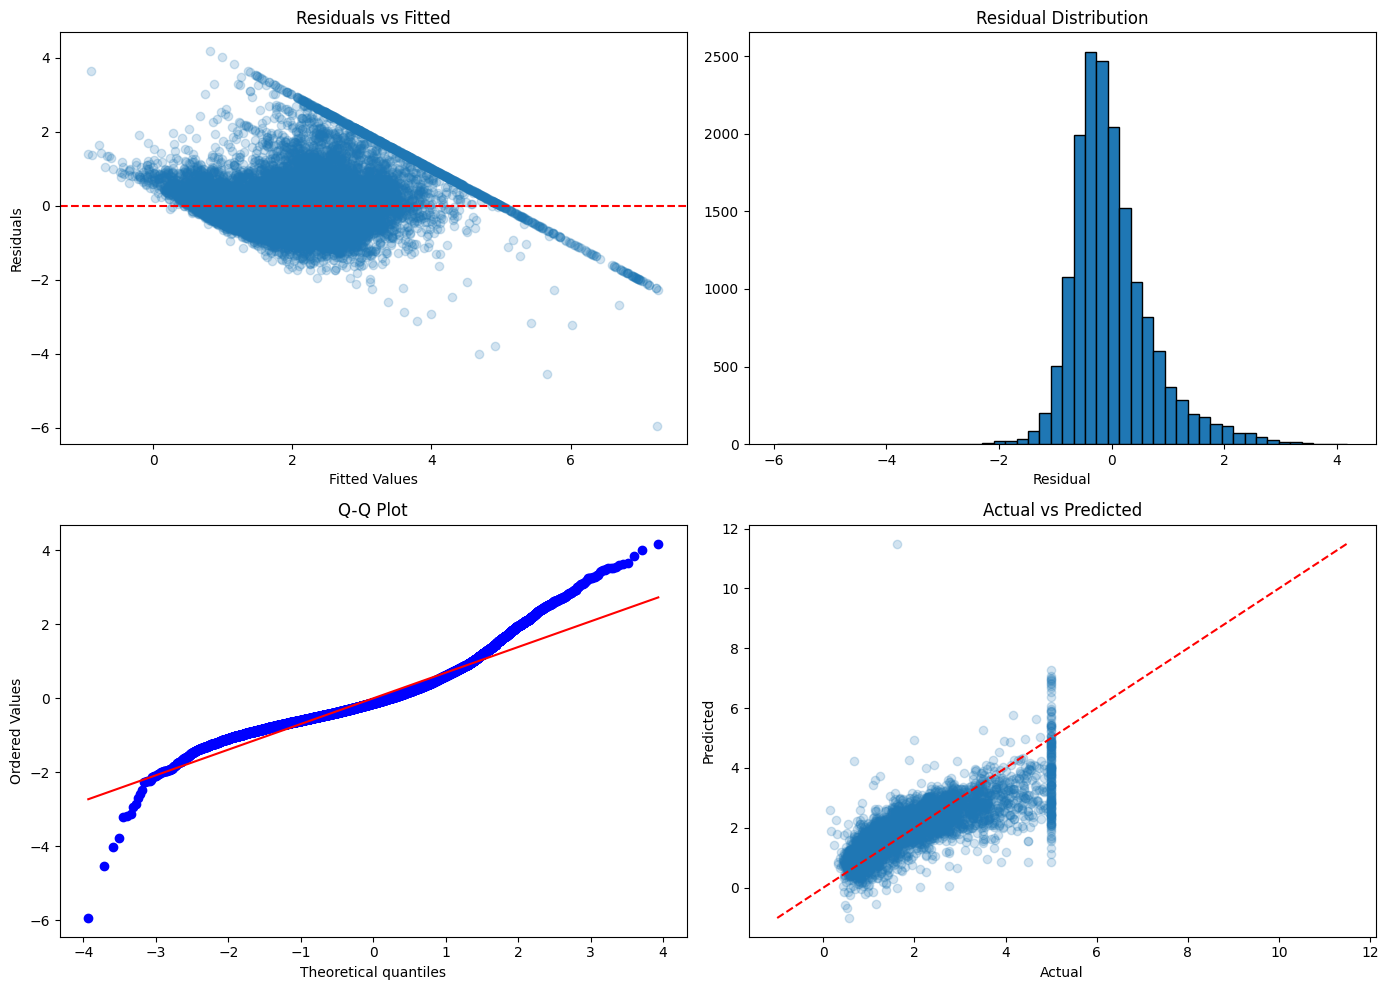

In [112]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs fitted
axes[0, 0].scatter(
    y_train_pred,
    residuals,
    alpha=0.2
)
axes[0, 0].axhline(
    0,
    color="red",
    linestyle="--"
)
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")

# Residual histogram
axes[0, 1].hist(
    residuals,
    bins=50,
    edgecolor="black"
)
axes[0, 1].set_title("Residual Distribution")
axes[0, 1].set_xlabel("Residual")

# Q-Q plot
stats.probplot(
    residuals,
    dist="norm",
    plot=axes[1, 0]
)
axes[1, 0].set_title("Q-Q Plot")

# Actual vs predicted
axes[1, 1].scatter(
    y_test,
    y_pred,
    alpha=0.2
)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

axes[1, 1].plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--"
)

axes[1, 1].set_title("Actual vs Predicted")
axes[1, 1].set_xlabel("Actual")
axes[1, 1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

# 13. Statistical regression summary

In [116]:
display(ols_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            MedHouseVal   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     3261.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        22:36:26   Log-Likelihood:                -17998.
No. Observations:               16512   AIC:                         3.601e+04
Df Residuals:                   16503   BIC:                         3.608e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -37.0233      0.728    -50.835      0.000     -38.451     -35.596
MedInc         0.4487      0.005     95.697      0.000       0.439       0.458
HouseAge       0.0097      0.000     19.665      0.000       0.009       0.011
AveRooms      -0.1233      0.007    -18.677      0.000      -0.136      -0.110
AveBedrms      0.7831      0.033     23.556      0.000       0.718       0.848
Population  -2.03e-06   5.25e-06     -0.387      0.699   -1.23e-05    8.26e-06
AveOccup      -0.0035      0.000     -7.253      0.000      -0.004      -0.003
Latitude      -0.4198      0.008    -52.767      0.000      -0.435      -0.404
Longitude     -0.4337      0.008    -52.117      0.000      -0.450      -0.417
==============================================================================
Omnibus:                     3333.187   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9371.466
Skew:                           1.071   Prob(JB):                         0.00
Kurtosis:                       6.006   Cond. No.                     2.38e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.38e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# 14. Hypothetical Predictions

In [117]:
hypothetical = pd.DataFrame({
    "MedInc": [3.0, 5.0, 8.0],
    "HouseAge": [20.0, 30.0, 15.0],
    "AveRooms": [5.0, 6.0, 7.0],
    "AveBedrms": [1.0, 1.2, 1.0],
    "Population": [800.0, 1500.0, 600.0],
    "AveOccup": [3.0, 2.8, 2.5],
    "Latitude": [34.0, 37.0, 38.0],
    "Longitude": [-118.0, -122.0, -121.0]
})

display(hypothetical)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,3.0,20.0,5.0,1.0,800.0,3.0,34.0,-118.0
1,5.0,30.0,6.0,1.2,1500.0,2.8,37.0,-122.0
2,8.0,15.0,7.0,1.0,600.0,2.5,38.0,-121.0


In [119]:
### --- Prediction ---

hypothetical_predictions = model.predict(hypothetical)

prediction_table = hypothetical.copy()

prediction_table["PredictedMedHouseVal"] = hypothetical_predictions

display(prediction_table)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PredictedMedHouseVal
0,3.0,20.0,5.0,1.0,800.0,3.0,34.0,-118.0,1.576165
1,5.0,30.0,6.0,1.2,1500.0,2.8,37.0,-122.0,3.078802
2,8.0,15.0,7.0,1.0,600.0,2.5,38.0,-121.0,3.148395


In [121]:
"""
Target is expressed in units of $100,000, 
convert the predictions to dollars:
"""

prediction_table["PredictedPrice_$"] = (
    prediction_table["PredictedMedHouseVal"] * 100_000
)

display(
    prediction_table[
        ["PredictedMedHouseVal", "PredictedPrice_$"]
    ]
)

,PredictedMedHouseVal,PredictedPrice_$
0,1.576165,157616.483577
1,3.078802,307880.219819
2,3.148395,314839.474275
